In [11]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage, ToolMessage
from typing import TypedDict, Sequence, Annotated
from langchain_core.output_parsers import StrOutputParser
from langchain.tools import tool
from langgraph.graph import StateGraph, START, END, add_messages
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.types import interrupt, Command
from dotenv import load_dotenv

load_dotenv()

True

In [12]:
class AgentState(TypedDict):
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [13]:
llm = ChatGoogleGenerativeAI(model='gemini-3.1-flash-lite-preview')

In [14]:
checkpointer = InMemorySaver()

In [15]:
@tool(name_or_callable='make_payment', description='Make a payment to a specified recipient')
def make_payment(recipient: str, amount: float) -> str:
    print(f"#### TOOL CALLED: 'make_payment', args: recipient={recipient}, amount={amount} ####")
    return f"Payment of ${amount} made to {recipient}."

@tool(name_or_callable='check_balance', description='Check the account balance')
def check_balance() -> str:
    print(f"#### TOOL CALLED: 'check_balance' ####")
    import random
    return f"Your current balance is ${random.randint(500, 2000)}."

In [16]:
tools = [make_payment, check_balance]
llm_with_tools = llm.bind_tools(tools)

In [ ]:
def llm_node(state: AgentState) -> AgentState:
    # res = llm_with_tools.invoke(state['messages'])
    res = llm_with_tools.invoke(state['messages'])

    approved = 'yes'

    if res.tool_calls and res.tool_calls[0]['name'] == 'make_payment':
        print("Payment action detected. Requesting human approval...")
        approved = interrupt("Do you want to approve the payment?  (yes/no)")

    if approved.lower() == 'yes':
        return {'messages': [res]}
    else:
        res = AIMessage(content="Payment not approved. Operation cancelled.")
        return {'messages': [res]}


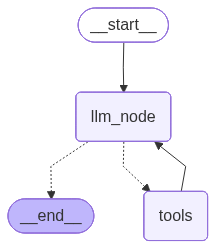

In [18]:
graph = StateGraph(AgentState)

graph.add_node('llm_node', llm_node)
graph.add_node('tools', ToolNode(tools))

graph.add_edge(START, 'llm_node')
graph.add_conditional_edges(
    'llm_node',
    tools_condition
)
graph.add_edge('tools', 'llm_node')

app = graph.compile(checkpointer=checkpointer)

app

In [19]:
config = {
    'configurable': {
        'thread_id': 'agent_thread_1'
    }
}

In [20]:
messages = []
while True:
    user_input = input("User: ")
    if user_input.lower() == "exit":
        break
    messages.append(HumanMessage(content=user_input))
    result = app.invoke({'messages': messages}, config=config)

    if result.get('__interrupt__'):
        interrupt_message = result['__interrupt__'][0].value
        print(f"Action required: {interrupt_message}")
        user_response = input("Your response: ")

        result = app.invoke(Command(resume=user_response), config=config)

    print(f"AI: {StrOutputParser().invoke(result['messages'][-1])}")
    messages.append(result['messages'][-1])

Payment action detected. Requesting human approval...
Action required: Do you want to approve the payment?  (yes/no)
Payment action detected. Requesting human approval...
#### TOOL CALLED: 'make_payment', args: recipient=Tara, amount=45.0 ####
AI: OK. I've made a payment of $45 to Tara.
Payment action detected. Requesting human approval...
Action required: Do you want to approve the payment?  (yes/no)
Payment action detected. Requesting human approval...
AI: Payment not approved. Operation cancelled.
#### TOOL CALLED: 'check_balance' ####
AI: Your current balance is $1190.
AI: I made a payment of $45 to Tara, and the payment to Sam was cancelled.


### Interrput Output Sample
```code
{'messages': [HumanMessage(content='Make a payment of $100 to John Doe', additional_kwargs={}, response_metadata={}, id='98518d30-3d22-4e83-ad6c-558574292385')],
 '__interrupt__': [Interrupt(value='Do you want to approve the payment?  (yes/no)', id='f35017ca34d918fac9c60583be51068d')]}
 ```

In [21]:
app.invoke({'messages': 'Make a payment of $100 to John Doe'}, config=config)

Payment action detected. Requesting human approval...


{'messages': [HumanMessage(content='Make a payment to Tara for $45', additional_kwargs={}, response_metadata={}, id='dff5b5fa-b86e-435e-890f-9b534c3d4092'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'make_payment', 'arguments': '{"recipient": "Tara", "amount": 45}'}, '__gemini_function_call_thought_signatures__': {'9d1e0333-dc51-44d3-923f-aaeff8fd4b7b': 'EjQKMgEMOdbHXjvpZyLduzTg3d1JgcPeuor7K6YOw9R5+1sJB7uRNrVw27pY+ONTsJHRTuUD'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--7afc09e1-8ec9-4eeb-be3a-f4615099b5f8-0', tool_calls=[{'name': 'make_payment', 'args': {'recipient': 'Tara', 'amount': 45}, 'id': '9d1e0333-dc51-44d3-923f-aaeff8fd4b7b', 'type': 'tool_call'}], usage_metadata={'input_tokens': 83, 'output_tokens': 21, 'total_tokens': 104, 'input_token_details': {'cache_read': 0}}),
  T

In [22]:
app.invoke(Command(resume='yes'), config=config)

Payment action detected. Requesting human approval...
#### TOOL CALLED: 'make_payment', args: recipient=John Doe, amount=100.0 ####


{'messages': [HumanMessage(content='Make a payment to Tara for $45', additional_kwargs={}, response_metadata={}, id='dff5b5fa-b86e-435e-890f-9b534c3d4092'),
  AIMessage(content=[], additional_kwargs={'function_call': {'name': 'make_payment', 'arguments': '{"recipient": "Tara", "amount": 45}'}, '__gemini_function_call_thought_signatures__': {'9d1e0333-dc51-44d3-923f-aaeff8fd4b7b': 'EjQKMgEMOdbHXjvpZyLduzTg3d1JgcPeuor7K6YOw9R5+1sJB7uRNrVw27pY+ONTsJHRTuUD'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite-preview', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--7afc09e1-8ec9-4eeb-be3a-f4615099b5f8-0', tool_calls=[{'name': 'make_payment', 'args': {'recipient': 'Tara', 'amount': 45}, 'id': '9d1e0333-dc51-44d3-923f-aaeff8fd4b7b', 'type': 'tool_call'}], usage_metadata={'input_tokens': 83, 'output_tokens': 21, 'total_tokens': 104, 'input_token_details': {'cache_read': 0}}),
  T